In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import cv2
import torch
from torch.utils.data import Dataset

In [2]:
base_path = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"

In [3]:
label_map = {
    "COVID": 0,
    "Normal": 1,
    "Lung_Opacity": 2,
    "Viral Pneumonia": 3
}

In [4]:
image_paths = []
labels = []

In [5]:
for class_name in label_map:

    folder = os.path.join(
        base_path,
        class_name,
        "images"
    )

    for image_name in os.listdir(folder):

        image_paths.append(
            os.path.join(folder, image_name)
        )

        labels.append(
            label_map[class_name]
        )

In [6]:
print(len(image_paths))
print(len(labels))

21165
21165


In [7]:
print(image_paths[0])
print(labels[0])

/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images/COVID-1994.png
0


In [17]:
class ChestXrayDataset(Dataset):

    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

In [18]:
    def __len__(self):

        return len(self.image_paths)

In [19]:
dataset = ChestXrayDataset(
    image_paths,
    labels
)

In [20]:
len(dataset)

21165

In [24]:
class ChestXrayDataset(Dataset):

    def __init__(self, image_paths, labels):

        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.image_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            (224,224)
        )

        image = image / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        image = image.unsqueeze(0)

        label = self.labels[idx]

        return image, label

In [25]:
dataset = ChestXrayDataset(
    image_paths,
    labels
)

In [26]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([1, 224, 224])
0


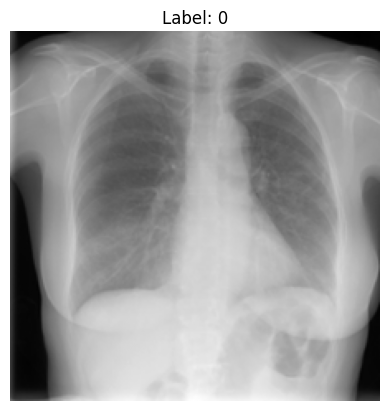

In [27]:
import matplotlib.pyplot as plt

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"Label: {label}")

plt.axis("off")

plt.show()